# Lab for week 7

In the previous labs, we learned how to load, clean, explore, and visualize data. This week, we will do a machine learning workflow: turning clean data into a **trained model** that can make predictions.

**Dataset:** `fruit_data_with_colors.txt`: A small dataset of fruits with the following columns:

| Column | Description |
|---|---|
| `fruit_label` | Numeric label for the fruit type (target, encoded) |
| `fruit_name` | Fruit type: apple, mandarin, orange, lemon |
| `fruit_subtype` | Sub-variety of the fruit |
| `mass` | Mass of the fruit, in grams |
| `width` | Width of the fruit, in cm |
| `height` | Height of the fruit, in cm |
| `color_score` | A numeric score representing the fruit's color |

In [ ]:
#!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

In [403]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [404]:
# Load the dataset
fruits = pd.read_csv('fruit_data_with_colors.txt', sep='\t')

In [405]:
# First look
print(f"Shape: {fruits.shape}")
fruits.head()

Shape: (60, 7)


,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,corrupt
4,2,mandarin,mandarin,84,6.0,4.6,0.79


In [406]:
fruits.tail()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
55,4,lemon,unknown,116,6.1,8.5,0.71
56,4,lemon,unknown,116,6.3,7.7,0.72
57,4,lemon,unknown,116,5.9,8.1,0.73
58,4,lemon,unknown,152,6.5,8.5,0.72
59,4,lemon,unknown,118,6.1,8.1,0.70


In [407]:
fruits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   fruit_label    60 non-null     int64  
 1   fruit_name     60 non-null     object 
 2   fruit_subtype  60 non-null     object 
 3   mass           60 non-null     int64  
 4   width          60 non-null     float64
 5   height         59 non-null     float64
 6   color_score    60 non-null     object 
dtypes: float64(2), int64(2), object(3)
memory usage: 3.4+ KB


## Checking Unique Values

Before we clean anything, it helps to know what values each column actually contains.

In [408]:
# Number of unique values per column
fruits.nunique()

fruit_label       4
fruit_name        4
fruit_subtype    10
mass             40
width            24
height           28
color_score      28
dtype: int64

In [409]:
# Actual unique values for the categorical columns
print("Fruit names:", fruits['fruit_name'].unique())
print("Fruit subtypes:", fruits['fruit_subtype'].unique())

Fruit names: ['apple' 'mandarin' 'orange' 'lemon']
Fruit subtypes: ['granny_smith' 'mandarin' 'braeburn' 'golden_delicious' 'cripps_pink'
 'spanish_jumbo' 'selected_seconds' 'turkey_navel' 'spanish_belsan'
 'unknown']


In [410]:
# Confirm fruit_label maps 1:1 with fruit_name (no label used for two different fruits, etc.)
fruits[['fruit_label', 'fruit_name']].drop_duplicates().sort_values('fruit_label')

,fruit_label,fruit_name
0,1,apple
3,2,mandarin
25,3,orange
44,4,lemon


## Checking for Duplicate Rows

Duplicate rows can silently bias a model, if the same fruit measurement appears multiple times, the model effectively "sees" it more often during training, giving it more influence than it should have.

In [411]:
# Check for fully duplicated rows
fruits[fruits.duplicated(keep=False)]

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
7,2,mandarin,mandarin,76,5.8,4.0,0.81
8,2,mandarin,mandarin,76,5.8,4.0,0.81


In [412]:
print(f"Number of duplicate rows: {fruits.duplicated().sum()}")
fruits[fruits.duplicated()]

Number of duplicate rows: 1


,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
8,2,mandarin,mandarin,76,5.8,4.0,0.81


Since these are exact duplicate rows, we'll drop them, keeping only the first occurrence.

In [413]:
# Drop duplicate rows, keeping the first occurrence
fruits = fruits.drop_duplicates().reset_index(drop=True)

print(f"Shape after dropping duplicates: {fruits.shape}")

Shape after dropping duplicates: (59, 7)


## Checking for Missing Values

Missing values need to be handled before modeling, most algorithms (including k-NN) can't work with `NaN`s directly. Before deciding *how* to handle them, we first need to know *where* they are and *how many* there are.

In [414]:
# Count of missing values per column
fruits.isnull().sum()

fruit_label      0
fruit_name       0
fruit_subtype    0
mass             0
width            0
height           1
color_score      0
dtype: int64

In [415]:
# Inspect the row with the missing height
fruits[fruits['height'].isnull()]

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
11,1,apple,braeburn,172,7.1,NaN,0.92


### Why not just fill with the global mean height?

Usually we go for `fruits['height'].mean()` and fill every missing value with it. But think about what it actually assumes: that this fruit's height is close to the *average height of all fruits in the dataset*, regardless of what fruit it is.

Apples, oranges, mandarins, and lemons are very different shapes and sizes. If the global mean height is being pulled up by large oranges, filling an apple's missing height with that global mean could give it a value that's unrealistic for an apple.

In [416]:
# Filter to only apple rows
apple_rows = fruits[fruits['fruit_name'] == 'apple']
apple_rows

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
8,1,apple,braeburn,178,7.1,7.8,0.92
9,1,apple,braeburn,172,7.4,7.0,0.89
10,1,apple,braeburn,166,6.9,7.3,0.93
11,1,apple,braeburn,172,7.1,NaN,0.92
12,1,apple,braeburn,154,7.0,7.1,0.88
13,1,apple,golden_delicious,164,7.3,7.7,0.70
14,1,apple,golden_delicious,152,7.6,7.3,0.69


In [417]:
# Compute the mean height from those rows
apple_mean_height = apple_rows['height'].mean()

# Inspect the computed value before using it to fill
print(f"Mean height for apples: {apple_mean_height:.2f}")

Mean height for apples: 7.33


In [418]:
# Fill the missing height using this fruit-specific mean
fruits['height'] = fruits['height'].fillna(apple_mean_height)

In [419]:
# Confirm no missing values remain
fruits['height'].isnull().sum()

np.int64(0)

## Checking for Invalid Values

A column can pass the missing-value check and still be unusable, for example, a numeric column stored as text, or a single corrupted entry hiding among otherwise valid numbers.

In [420]:
# Check dtypes of all columns
fruits.dtypes

fruit_label        int64
fruit_name        object
fruit_subtype     object
mass               int64
width            float64
height           float64
color_score       object
dtype: object

Notice that `color_score` shows up as `object`, while `mass`, `width`, and `height`, all similar physical measurements, come back as `float64`. 

`color_score` is described as a numeric score, so it should logically be a numeric dtype too. 

In [421]:
fruits.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,corrupt
4,2,mandarin,mandarin,84,6.0,4.6,0.79


In [422]:
# Convert to numeric; anything that fails becomes NaN instead of raising an error
fruits['color_score'] = pd.to_numeric(fruits['color_score'], errors='coerce')

In [423]:
# Compute the mean color_score for that fruit type, using only the clean (numeric) values

mandarin_rows = fruits[fruits['fruit_name'] == 'mandarin']
mandarin_rows

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
3,2,mandarin,mandarin,86,6.2,4.7,NaN
4,2,mandarin,mandarin,84,6.0,4.6,0.79
5,2,mandarin,mandarin,80,5.8,4.3,0.77
6,2,mandarin,mandarin,80,5.9,4.3,0.81
7,2,mandarin,mandarin,76,5.8,4.0,0.81


In [424]:
mandarin_mean_color = mandarin_rows['color_score'].mean()

In [425]:
fruits['color_score'] = fruits['color_score'].fillna(mandarin_mean_color)

In [426]:
fruits['color_score'].dtype

dtype('float64')

## Exploratory Data Analysis (EDA)

EDA helps us see patterns, spot relationships between features, and catch anything that might affect how we model this data (like class imbalance or weak predictors) before we get to training.

In [427]:
# Quick statistical summary of all numeric columns
fruits.describe()

,fruit_label,mass,width,height,color_score
count,59.000000,59.000000,59.000000,59.000000,59.000000
mean,2.542373,163.118644,7.105085,7.688606,0.762797
std,1.208048,55.018832,0.816938,1.361800,0.076819
min,1.000000,76.000000,5.800000,4.000000,0.550000
25%,1.000000,140.000000,6.600000,7.200000,0.720000
50%,3.000000,158.000000,7.200000,7.600000,0.750000
75%,4.000000,177.000000,7.500000,8.200000,0.810000
max,4.000000,362.000000,9.600000,10.500000,0.930000


In [428]:
# Target distribution: How many of each fruit type do we have?

fruits['fruit_name'].value_counts()

fruit_name
apple       19
orange      19
lemon       16
mandarin     5
Name: count, dtype: int64

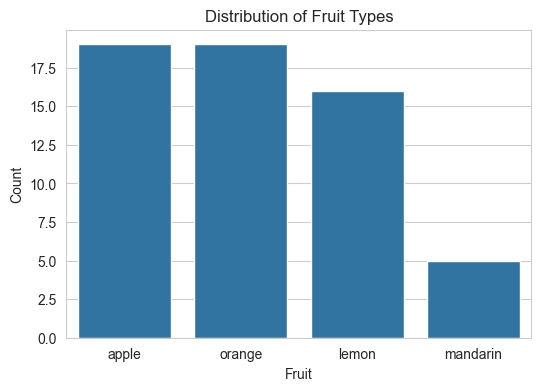

In [429]:
# Visualize it
plt.figure(figsize=(6, 4))
sns.countplot(data=fruits, x='fruit_name', order=fruits['fruit_name'].value_counts().index)
plt.title('Distribution of Fruit Types')
plt.xlabel('Fruit')
plt.ylabel('Count')
plt.show()

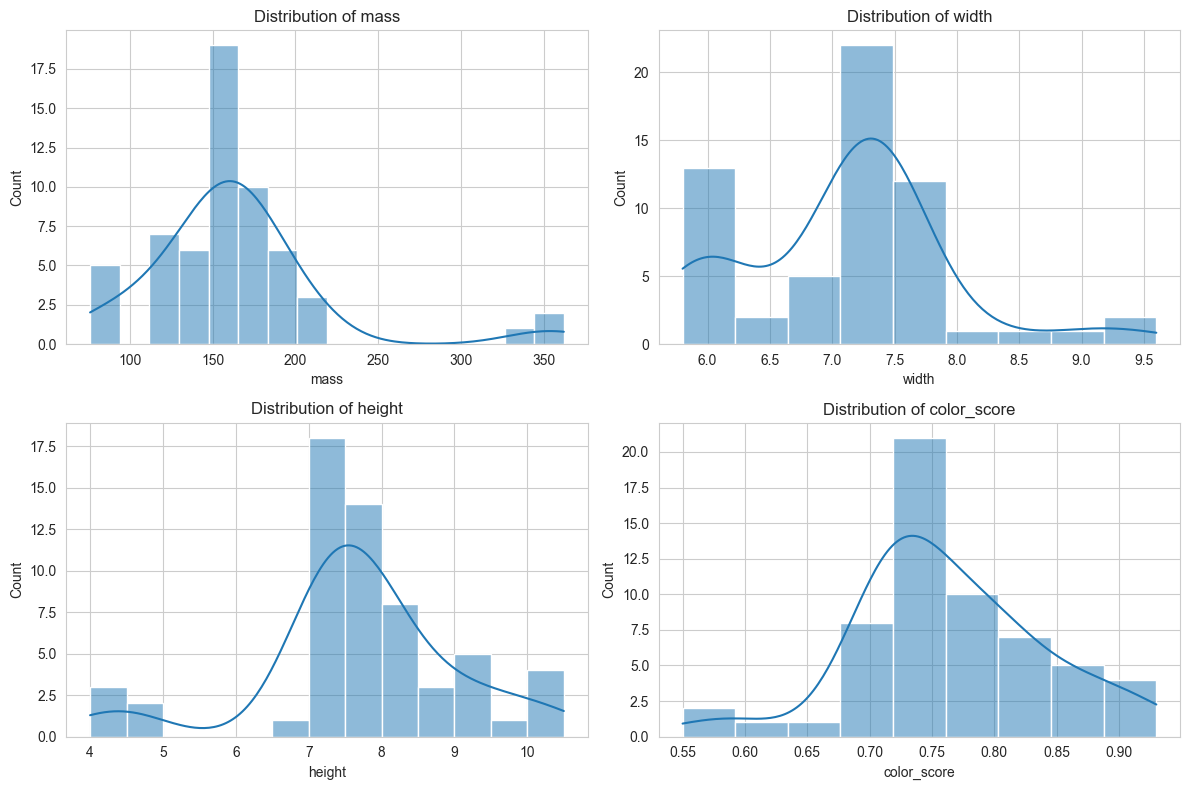

In [430]:
# Univariate distributions of the numeric features
numeric_cols = ['mass', 'width', 'height', 'color_score']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=fruits, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

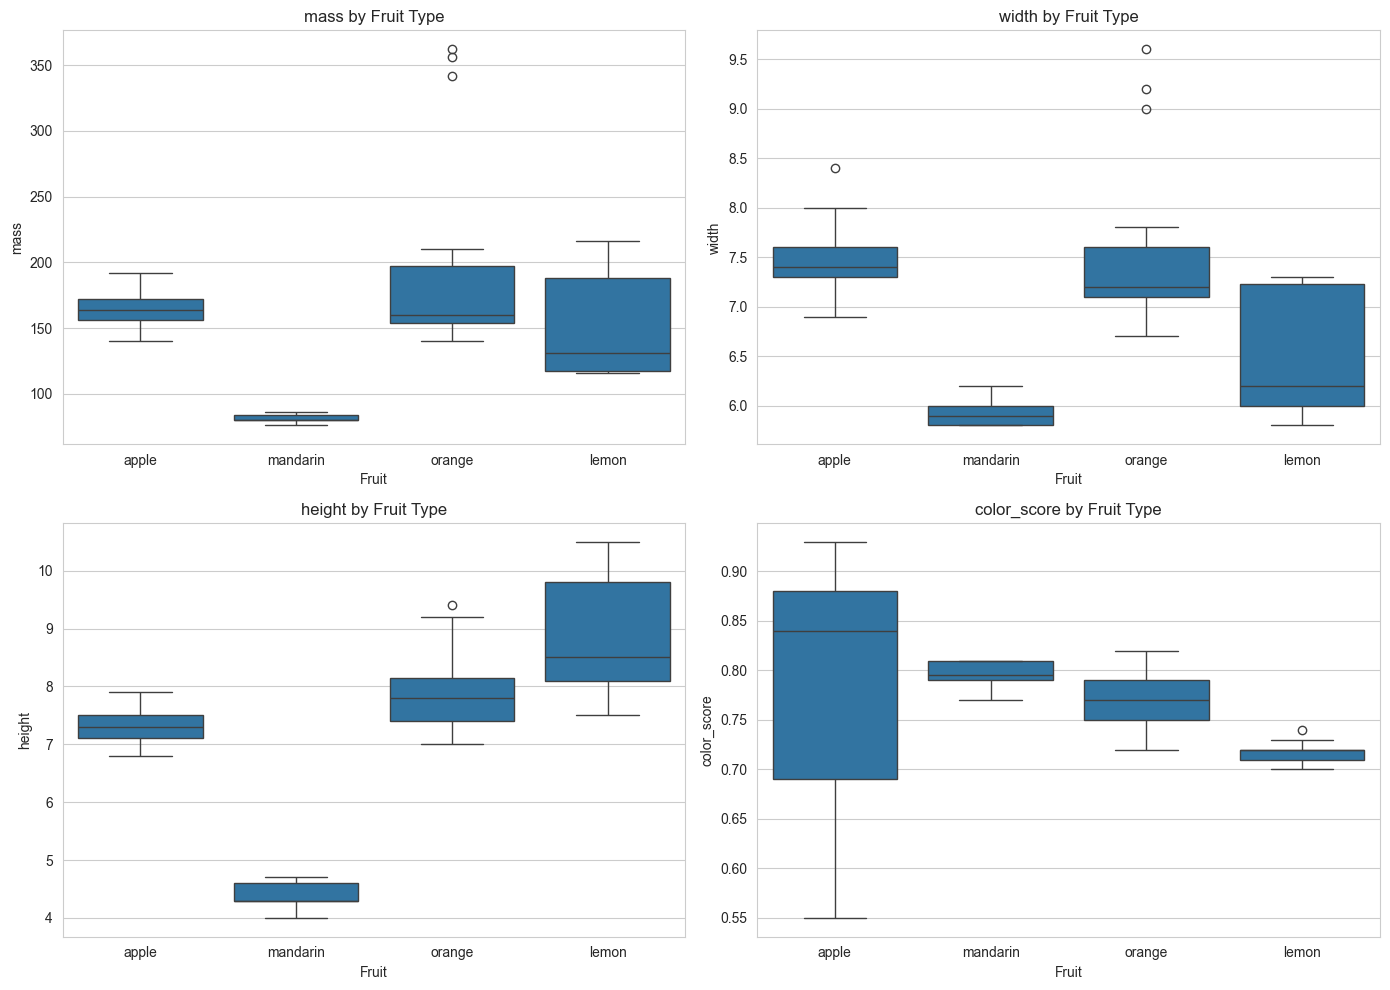

In [431]:
# Boxplots per feature, split by fruit type
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=fruits, x='fruit_name', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Fruit Type')
    axes[i].set_xlabel('Fruit')

plt.tight_layout()
plt.show()

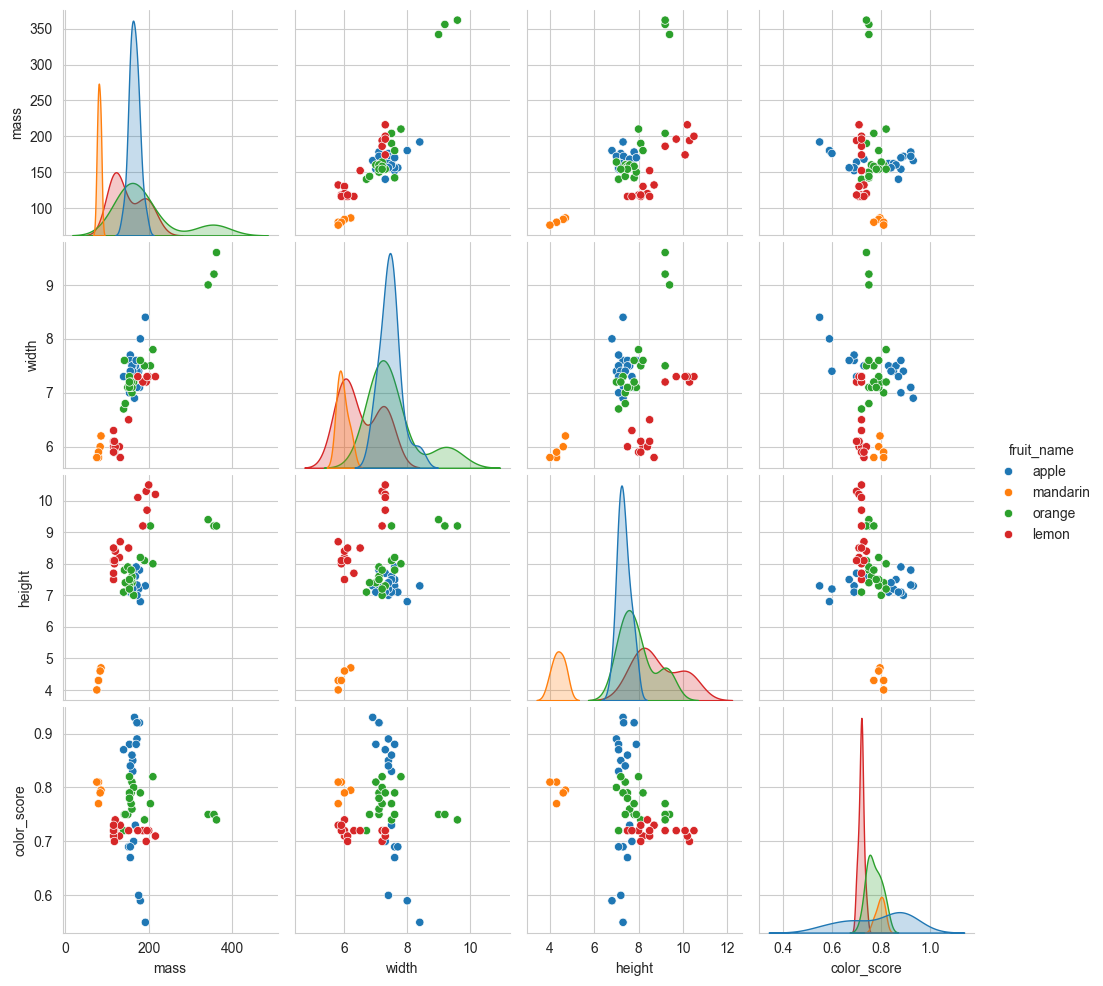

In [432]:
# Pairplot, colored by fruit type

sns.pairplot(fruits, vars=numeric_cols, hue='fruit_name')
plt.show()

### Outlier Detection (IQR Method)

Even after cleaning missing and corrupt values, a dataset can still contain outliers. The IQR (Interquartile Range) method flags any value that falls far outside the typical spread of a feature, using the 25th and 75th percentiles as reference points.

In [433]:
# IQR-based outlier detection for each numeric feature
for col in numeric_cols:
    Q1 = fruits[col].quantile(0.25)
    Q3 = fruits[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = fruits[(fruits[col] < lower_bound) | (fruits[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outlier(s) : Bounds [{lower_bound:.2f}, {upper_bound:.2f}]")

mass: 7 outlier(s) : Bounds [84.50, 232.50]
width: 3 outlier(s) : Bounds [5.25, 8.85]
height: 10 outlier(s) : Bounds [5.70, 9.70]
color_score: 1 outlier(s) : Bounds [0.58, 0.95]


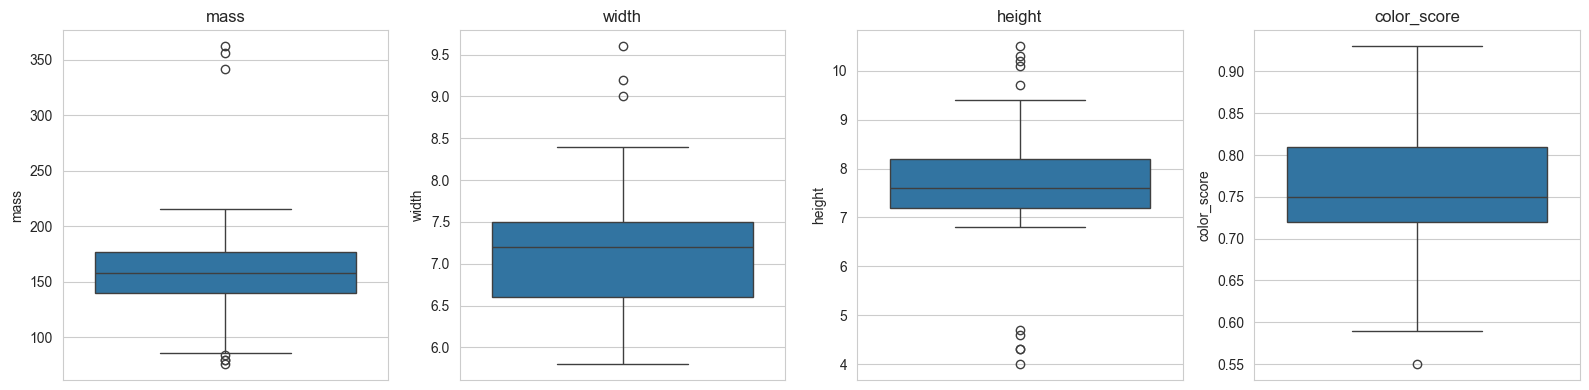

In [434]:
# Visualize outliers directly using boxplots (already familiar from the IQR concept)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=fruits, y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Categorical vs. Numerical Features

Before moving into encoding and scaling, it helps to explicitly separate our features into two groups, since each type needs different treatment. Numerical features may need scaling; categorical features need encoding.

In [435]:
# Split columns into categorical and numerical
categorical_cols = fruits.select_dtypes(include='object').columns.tolist()
numerical_cols = fruits.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['fruit_name', 'fruit_subtype']
Numerical columns: ['fruit_label', 'mass', 'width', 'height', 'color_score']


## Encoding Categorical Features


In [436]:
# Check how many unique subtypes exist, and their distribution
fruits['fruit_subtype'].value_counts()

fruit_subtype
turkey_navel        10
unknown             10
cripps_pink          6
selected_seconds     6
spanish_belsan       6
mandarin             5
braeburn             5
golden_delicious     5
granny_smith         3
spanish_jumbo        3
Name: count, dtype: int64

In [437]:
fruits.groupby('fruit_name')['fruit_subtype'].unique()

fruit_name
apple       [granny_smith, braeburn, golden_delicious, cripps_pink]
lemon                                     [spanish_belsan, unknown]
mandarin                                                 [mandarin]
orange              [spanish_jumbo, selected_seconds, turkey_navel]
Name: fruit_subtype, dtype: object

`fruit_subtype` has several distinct categories (e.g. `braeburn`, `cripps_pink`, `spanish_jumbo`, `turkey_navel`...) with **no inherent order** between them, one subtype isn't mathematically "more" or "less" than another. 

**One-hot encoding** is the right choice here: it creates a separate binary column per subtype, with no implied ranking between categories.

In [438]:
# One-hot encode fruit_subtype
fruits = pd.get_dummies(fruits, columns=['fruit_subtype'], prefix='subtype')
fruits.head()

,fruit_label,fruit_name,mass,width,height,color_score,subtype_braeburn,subtype_cripps_pink,subtype_golden_delicious,subtype_granny_smith,subtype_mandarin,subtype_selected_seconds,subtype_spanish_belsan,subtype_spanish_jumbo,subtype_turkey_navel,subtype_unknown
0,1,apple,192,8.4,7.3,0.550,False,False,False,True,False,False,False,False,False,False
1,1,apple,180,8.0,6.8,0.590,False,False,False,True,False,False,False,False,False,False
2,1,apple,176,7.4,7.2,0.600,False,False,False,True,False,False,False,False,False,False
3,2,mandarin,86,6.2,4.7,0.795,False,False,False,False,True,False,False,False,False,False
4,2,mandarin,84,6.0,4.6,0.790,False,False,False,False,True,False,False,False,False,False


In [439]:
# Confirm the new columns
fruits.columns.tolist()

['fruit_label',
 'fruit_name',
 'mass',
 'width',
 'height',
 'color_score',
 'subtype_braeburn',
 'subtype_cripps_pink',
 'subtype_golden_delicious',
 'subtype_granny_smith',
 'subtype_mandarin',
 'subtype_selected_seconds',
 'subtype_spanish_belsan',
 'subtype_spanish_jumbo',
 'subtype_turkey_navel',
 'subtype_unknown']

## Choosing Important Features

Now that all our columns are numeric, we can compute a correlation matrix to see how strongly each feature relates to the target (`fruit_label`) and to each other. This helps us decide which features are worth keeping, and flags redundant features that move together (multicollinearity).

In [440]:
# Compute the correlation matrix
corr_matrix = fruits.corr(numeric_only=True)

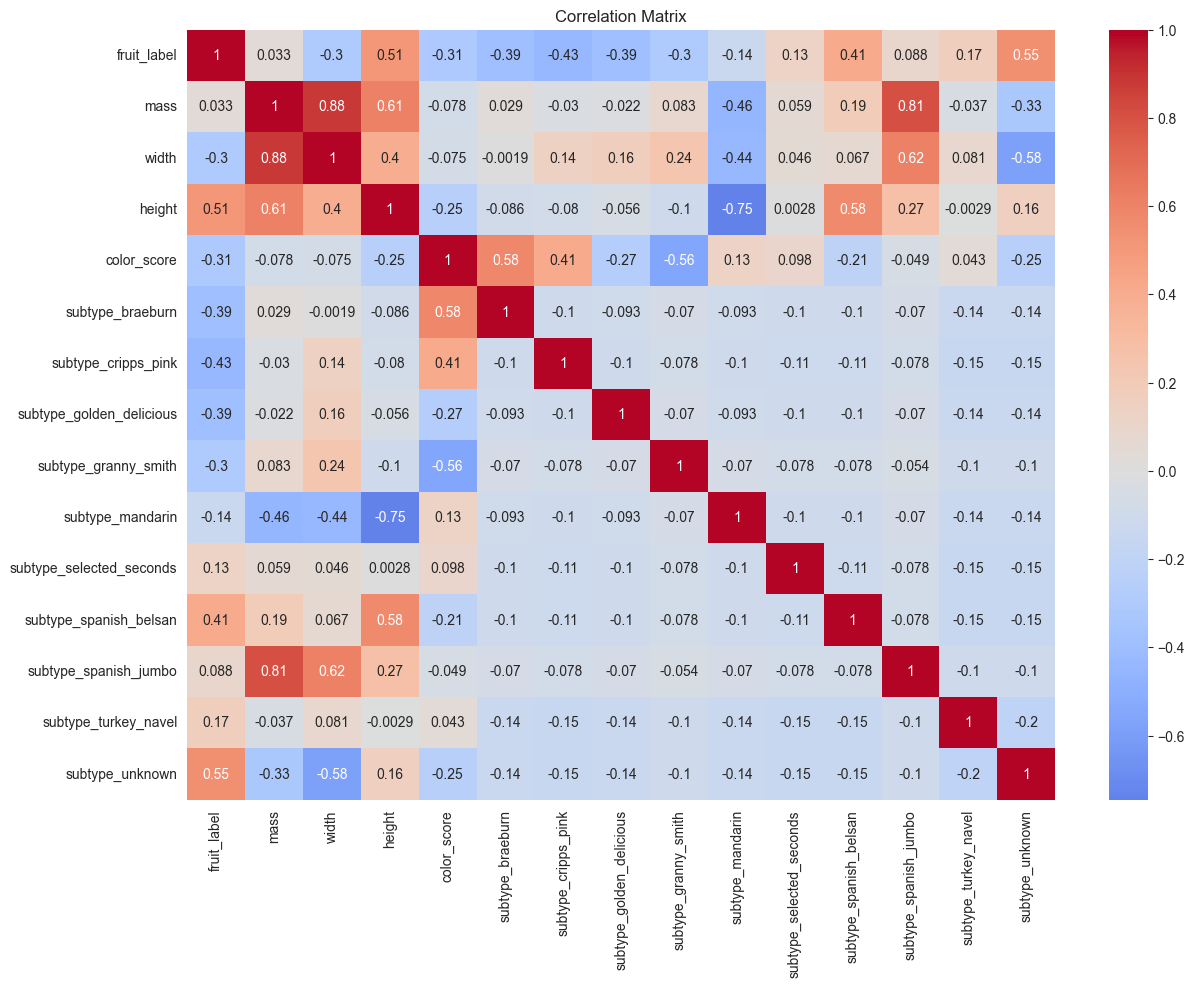

In [441]:
# Visualize it as a heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

### Correlation with a nominal target

Correlation with `fruit_label` is a useful signal, but it comes with a problem: `fruit_label` is a **nominal** target, the numbers 1, 2, 3, 4 are arbitrary category IDs, not a meaningful scale. So a weak correlation (like `mass` at 0.033) doesn't necessarily mean a feature is unimportant, it means Pearson correlation isn't well-suited to measuring its relationship with a nominal target in the first place. For that, the boxplots and pairplot from earlier are more trustworthy.

More importantly, notice the `subtype_*` columns correlate *unusually* strongly with `fruit_label`, e.g. `subtype_unknown` (0.55). This is because each subtype belongs to exactly one fruit (`braeburn` is always an apple, `spanish_belsan` is always an orange). Using these as model features would be **target leakage**, the model would learn to read the fruit type almost directly off the subtype, rather than genuinely learning from physical measurements. This is why we'll exclude the `subtype_*` columns from our feature set, even though we've encoded them.

In [442]:
# Final feature set, excluding color_score (weak) and subtype_* (leakage)

feature_cols = ['mass', 'width', 'height']

X = fruits[feature_cols]
y = fruits['fruit_label']

X.head()

,mass,width,height
0,192,8.4,7.3
1,180,8.0,6.8
2,176,7.4,7.2
3,86,6.2,4.7
4,84,6.0,4.6


## Train/Test Split

Before going any further, we split the data into training and test sets. This has to happen **before** scaling and before handling class imbalance.

In [443]:
# Preprocessing & modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE

In [445]:
# Split into training and test sets (80/20), stratified to preserve class proportions

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (47, 3)
Test set: (12, 3)


## Feature Scaling

k-NN is a **distance-based** algorithm, it classifies a new point by looking at which labeled points are closest to it. That means the scale of each feature directly affects the result: if `mass` ranges from 76 to 362 while `height` ranges from 4 to 10, the distance calculation will be dominated almost entirely by `mass`, simply because its numbers are bigger, not because it's actually more important.

Scaling puts every feature on a comparable range, so no single feature unfairly dominates the distance calculation just because of its units.

In [446]:
# Fit the scaler on training data only, then transform both sets
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Handling Class Imbalance with SMOTE

We already saw that the fruit classes are imbalanced, apples and oranges dominate, while mandarins are rare. 

**SMOTE** (Synthetic Minority Oversampling Technique) addresses this by generating new, synthetic examples of the minority class, not by duplicating existing rows, but by creating plausible new points *between* existing minority-class points in feature space.

**Important** SMOTE must be applied **only to the training set, after the split**, not before. 

In [447]:
# Check exact class counts in the training set to know our constraint
y_train.value_counts()

fruit_label
3    15
1    15
4    13
2     4
Name: count, dtype: int64

In [448]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to oversample the minority class

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Check the class distribution after oversampling
y_train_resampled.value_counts()

/Users/anushkaojha/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


fruit_label
3    15
4    15
1    15
2    15
Name: count, dtype: int64

## Training a k-NN Classifier

With the data cleaned, encoded, scaled, and balanced, we can now train the model. We'll use k-Nearest Neighbors (k-NN), starting with k=5.

In [449]:
# Initialize and train the model

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_resampled, y_train_resampled)

KNeighborsClassifier(n_neighbors=3)

In [450]:
# Evaluate on the test set
knn.score(X_test_scaled, y_test)

0.75

In [452]:
# Predict on the test set
y_pred = knn.predict(X_test_scaled)

In [453]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

In [455]:
fruits.head()

,fruit_label,fruit_name,mass,width,height,color_score,subtype_braeburn,subtype_cripps_pink,subtype_golden_delicious,subtype_granny_smith,subtype_mandarin,subtype_selected_seconds,subtype_spanish_belsan,subtype_spanish_jumbo,subtype_turkey_navel,subtype_unknown
0,1,apple,192,8.4,7.3,0.550,False,False,False,True,False,False,False,False,False,False
1,1,apple,180,8.0,6.8,0.590,False,False,False,True,False,False,False,False,False,False
2,1,apple,176,7.4,7.2,0.600,False,False,False,True,False,False,False,False,False,False
3,2,mandarin,86,6.2,4.7,0.795,False,False,False,False,True,False,False,False,False,False
4,2,mandarin,84,6.0,4.6,0.790,False,False,False,False,True,False,False,False,False,False


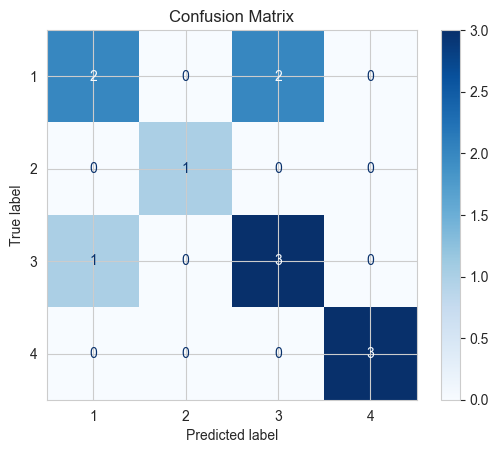

In [454]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

| Metric | What it means | Formula |
|---|---|---|
| **Precision** | Of everything the model predicted as this class, what fraction was actually correct? | $\dfrac{TP}{TP + FP}$ |
| **Recall** | Of everything that actually was this class, what fraction did the model correctly catch? | $\dfrac{TP}{TP + FN}$ |
| **F1-score** | Harmonic mean of precision and recall | $2 \times \dfrac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$ |
| **Support** | How many real examples of this class existed in the test set | *(count, not a formula)* |

Where, for a given class:
- **TP (True Positive)** : Model predicted this class, and it was correct
- **FP (False Positive)** : Model predicted this class, but it was actually a different class
- **FN (False Negative)** : Model predicted a different class, but it was actually this class

![screenshot](image.png)

In [456]:
# Classification report, precision, recall, and F1 per class

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.67      0.50      0.57         4
           2       1.00      1.00      1.00         1
           3       0.60      0.75      0.67         4
           4       1.00      1.00      1.00         3

    accuracy                           0.75        12
   macro avg       0.82      0.81      0.81        12
weighted avg       0.76      0.75      0.75        12



In [457]:
# A new, unseen fruit, measured mass, width, height

new_fruit = [[150, 7.3, 7.8]]  # mass, width, height

# Scale using the SAME scaler fitted on training data, transform only, no fit
new_fruit_scaled = scaler.transform(new_fruit)

# Predict
prediction = knn.predict(new_fruit_scaled)
print(f"Predicted label: {prediction[0]}")

Predicted label: 3


/Users/anushkaojha/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
